# Regularization loss landscapes — the magnitude-alignment view

**Goal:** push $W_{hh}$ to align with a spatial embedding *magnitude-wise*, i.e. raise $r(|W|, S)$ where $S = 1 - \text{kernel}$ is the spatial similarity. This notebook asks, for each regularizer in the training code (`neural_network.py`'s `regularization`), **does it create a downhill gradient in $r(|W|, S)$?**

The four losses:
1. **`l2s`** — $\|W\|^2 / n$ — penalizes magnitude only; *no* spatial structure.
2. **`l2` with embedding** — $\sum W^2 \cdot \text{kernel}$ — places squared weight on high-similarity (short-range) connections; rewards $r(|W|,S)$ *implicitly*.
3. **`pearson_l2s`** — $(1 - r(W, S)) + \|W\|^2 / n$ — rewards the **signed** correlation (sign-coupled; over-constrains E/I).
4. **`pearson_abs_l2s`** — $(1 - r(|W|, S)) + \|W\|^2 / n$ — rewards $r(|W|,S)$ *explicitly*; this is the objective.

Because the signed correlation $r(W,S)$ is scrambled by free E/I signs (it averages to ~0), every plot below uses **$r(|W|, S)$** as the primary axis, with $\|W\|$ (Frobenius norm) as the second. We sample $W$ by Monte Carlo — a linear $\alpha S + \beta R$ slice can't vary $r(|W|,S)$ independently of sign, so it can't surface this dimension.

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LightSource
from scipy.stats import binned_statistic, binned_statistic_2d

# Make `src` importable whether the notebook runs from the repo root or scripts/
import os, sys
_d = os.getcwd()
while _d != os.path.dirname(_d) and not os.path.isdir(os.path.join(_d, 'src')):
    _d = os.path.dirname(_d)
if os.path.isdir(os.path.join(_d, 'src')) and _d not in sys.path:
    sys.path.insert(0, _d)
from src.utils import set_font_size

# Increase font sizes throughout the notebook plots by a factor of 1.75 (12 -> 21)
set_font_size(16)

np.random.seed(42)

# --- Toy setup ---
n = 10
kernel = np.random.rand(n, n)
kernel = (kernel + kernel.T) / 2
np.fill_diagonal(kernel, 0)
kernel = kernel / kernel.max()

similarity = 1.0 - kernel
off_diag = ~np.eye(n, dtype=bool)

s_flat = similarity[off_diag]
s_flat_centered = s_flat - s_flat.mean()
s_flat_std = np.sqrt((s_flat_centered ** 2).sum())

# --- Loss functions (reference: scalar forms mirroring neural_network.py) ---
# The plots below use vectorized Monte-Carlo equivalents, but these document
# exactly what each `regularization` type computes on a single weight matrix W.
def compute_corr(W, use_abs=False):
    """Pearson r between off-diagonal weights (or |weights|) and similarity S."""
    w_flat = W[off_diag]
    if use_abs:
        w_flat = np.abs(w_flat)
    w_c = w_flat - w_flat.mean()
    w_std = np.sqrt((w_c ** 2).sum())
    if w_std < 0.01:
        return np.nan  # undefined at near-zero magnitude
    return (w_c @ s_flat_centered) / (w_std * s_flat_std)

def loss_l2s(W):
    """`l2s` (matrix=None): scaled L2 -> ||W||^2 / n"""
    return np.sum(W**2) / n

def loss_l2_embedding(W):
    """`l2` with embedding (matrix=kernel): sum(W^2 * kernel)"""
    return np.sum(W**2 * kernel)

def loss_pearson_l2s(W):
    """`pearson_l2s`: (1 - r(W, S)) + ||W||^2 / n"""
    r = compute_corr(W)
    return np.nan if np.isnan(r) else (1.0 - r) + np.sum(W**2) / n

def loss_pearson_abs_l2s(W):
    """`pearson_abs_l2s`: (1 - r(|W|, S)) + ||W||^2 / n"""
    r = compute_corr(W, use_abs=True)
    return np.nan if np.isnan(r) else (1.0 - r) + np.sum(W**2) / n

# Display order + LaTeX titles shared across all plots
LOSS_NAMES = ['l2s', 'l2 (embedding)', 'pearson_l2s', 'pearson_abs_l2s']
titles = {
    'l2s': r'$\|W\|^2 / n$',
    'l2 (embedding)': r'$\sum W^2 \cdot \mathrm{kernel}$',
    'pearson_l2s': r'$(1 - r(W, S)) + \|W\|^2 / n$',
    'pearson_abs_l2s': r'$(1 - r(|W|, S)) + \|W\|^2 / n$',
}

In [59]:
# --- Monte-Carlo backbone: sample weight directions AND magnitudes ---
# Each sample is a random unit direction scaled by a random Frobenius norm
# ||W|| in [0, mag_max]. To span the FULL achievable region of
# (signed r, magnitude r) we mix several generative modes with random weights:
#   a * s                    -> aligned: drives signed r AND r(|W|,S) to ±1 together
#   c * flatsign (flat |.|)  -> signs track sign(s - mean) with ~constant magnitude:
#                               injects signed r WITHOUT raising r(|W|,S)
#   mag_pat (pro/anti) * sgn -> sets r(|W|,S) via magnitude, random signs (signed r ~ 0)
#   b * noise                -> isotropic blur
# where pro = s and anti = max(s) - s.
np.random.seed(1)
N = 800_000
m_dim = len(s_flat)

pro = s_flat
anti = s_flat.max() - s_flat
flatsign = np.sign(s_flat_centered)       # +-1 tracking sign(s - mean), flat magnitude
sgn = np.random.choice([-1.0, 1.0], size=(N, m_dim))

a = np.random.randn(N, 1)                 # aligned s-direction (spans signed r & r_abs jointly)
c = np.random.randn(N, 1)                 # sign-tracking, flat magnitude (signed r at r_abs ~ 0)
b = np.random.randn(N, 1)                 # isotropic noise weight
g = np.abs(np.random.randn(N, 1))         # pro-aligned magnitude weight (>= 0)
h = np.abs(np.random.randn(N, 1))         # anti-aligned magnitude weight (>= 0)

mag_pat = g * (pro + 0.3 * np.random.rand(N, m_dim)) + h * (anti + 0.3 * np.random.rand(N, m_dim))
U = (a * s_flat
     + c * (flatsign * (1 + 0.2 * np.random.randn(N, m_dim)))   # flat magnitude, sign tracks s
     + b * np.random.randn(N, m_dim)
     + mag_pat * sgn)
U /= np.linalg.norm(U, axis=1, keepdims=True) + 1e-12     # unit directions

def batched_corr(M, use_abs=False):
    """Pearson r of each row of M (or |M|) against the similarity S."""
    if use_abs:
        M = np.abs(M)
    Mc = M - M.mean(axis=1, keepdims=True)
    denom = np.sqrt((Mc ** 2).sum(axis=1)) * s_flat_std
    return (Mc @ s_flat_centered) / (denom + 1e-12)

r_abs = batched_corr(U, use_abs=True)      # scale-invariant -> direction only
r_signed = batched_corr(U)

mag_max = 1.6 * np.linalg.norm(s_flat)
mags = np.random.uniform(0.0, mag_max, size=N)             # ||W|| for each sample

# Per-direction l2-embedding density (sum of U^2 * kernel over off-diagonal)
l2_per_unit = (U ** 2 * kernel[off_diag]).sum(axis=1)

# Losses at the sampled magnitude (W = mags * U); ||W||^2/n term = mags^2/n
loss_samples = {
    'l2s': mags ** 2 / n,
    'l2 (embedding)': mags ** 2 * l2_per_unit,
    'pearson_l2s': (1.0 - r_signed) + mags ** 2 / n,
    'pearson_abs_l2s': (1.0 - r_abs) + mags ** 2 / n,
}

# Losses at fixed ||W|| = 1 (isolates the correlation dependence)
unit_loss = {
    'l2s': np.full(N, 1.0 / n),
    'l2 (embedding)': l2_per_unit,
    'pearson_l2s': (1.0 - r_signed) + 1.0 / n,
    'pearson_abs_l2s': (1.0 - r_abs) + 1.0 / n,
}

# --- Bin into the (r(|W|,S), ||W||) plane: min achievable loss per cell ---
# 'min' = best the optimizer could reach at that (r_abs, ||W||). For
# pearson_abs_l2s the loss is an exact function of (r_abs, ||W||) so the binned
# surface is exact; for l2(embedding)/pearson_l2s it is an envelope (those
# losses are not single-valued in r_abs).
nb_r, nb_m = 70, 70
ra_edges = np.linspace(np.nanmin(r_abs), np.nanmax(r_abs), nb_r + 1)   # full domain
mag_edges = np.linspace(0.0, mag_max, nb_m + 1)
RA = 0.5 * (ra_edges[:-1] + ra_edges[1:])
MAG = 0.5 * (mag_edges[:-1] + mag_edges[1:])
RAg, MAGg = np.meshgrid(RA, MAG)

Z_ra = {}
for name in LOSS_NAMES:
    stat, _, _, _ = binned_statistic_2d(
        r_abs, mags, loss_samples[name], statistic='min', bins=[ra_edges, mag_edges])
    Z_ra[name] = stat.T   # indexed [magnitude, r_abs]

print(f"sampled r(|W|,S) range: [{r_abs.min():.2f}, {r_abs.max():.2f}]  "
      f"| signed r: [{r_signed.min():.2f}, {r_signed.max():.2f}]  "
      f"| ||W||: [0, {mag_max:.2f}]")

sampled r(|W|,S) range: [-0.94, 0.99]  | signed r: [-0.99, 0.99]  | ||W||: [0, 8.26]


## Headline: which losses reward magnitude-alignment?

At fixed $\|W\|$, how does each loss vary as $r(|W|,S)$ increases? A **downward** slope means the loss rewards alignment — minimizing it pushes $W$ toward the embedding magnitude-wise. Curves are min–max normalized so the *shape* (slope), not the absolute scale, is comparable across losses.

This plot uses the **typical** (median) loss at each $r(|W|,S)$. `pearson_abs_l2s` and `l2`-embedding slope down (they reward alignment); `l2s` is flat; **`pearson_l2s` is also flat** — its signed-correlation target is decoupled from magnitude alignment on average. (The later $(r_{\text{abs}}, \|W\|)$ landscapes use the *best-achievable* (min) loss instead, where `pearson_l2s` picks up a weak envelope slope only because high signed $r$ implies high $r_{\text{abs}}$ at the extreme.)

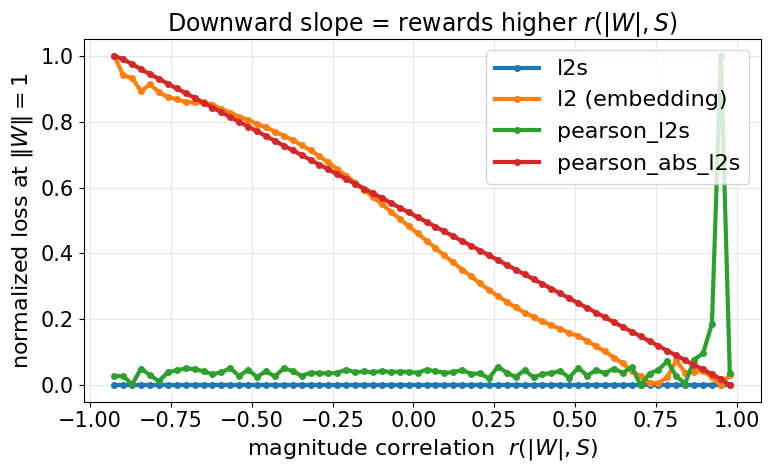

In [60]:
# --- Loss at ||W||=1 vs r(|W|,S) (min-max normalized) ---
ra_c = 0.5 * (ra_edges[:-1] + ra_edges[1:])
fig, ax = plt.subplots(figsize=(8, 5))

for name in LOSS_NAMES:
    med, _, _ = binned_statistic(r_abs, unit_loss[name], statistic='median', bins=ra_edges)
    mn, mx = np.nanmin(med), np.nanmax(med)
    norm = (med - mn) / (mx - mn) if mx > mn else np.zeros_like(med)
    ax.plot(ra_c, norm, lw=3, marker='o', ms=4, label=name)

ax.set_xlabel(r'magnitude correlation  $r(|W|, S)$')
ax.set_ylabel(r'normalized loss at $\|W\|=1$')
ax.set_title('Downward slope = rewards higher $r(|W|, S)$')
ax.grid(alpha=0.3)
ax.legend(frameon=True, loc='best')
plt.tight_layout()
plt.show()

## Loss landscapes in $(r(|W|, S),\ \|W\|)$ space

Min achievable loss over the magnitude-correlation / weight-norm plane. Look at the **horizontal** structure: losses that reward alignment have contours that descend as $r(|W|,S) \to 1$ (left→right), independent of the vertical $\|W\|$ bowl.

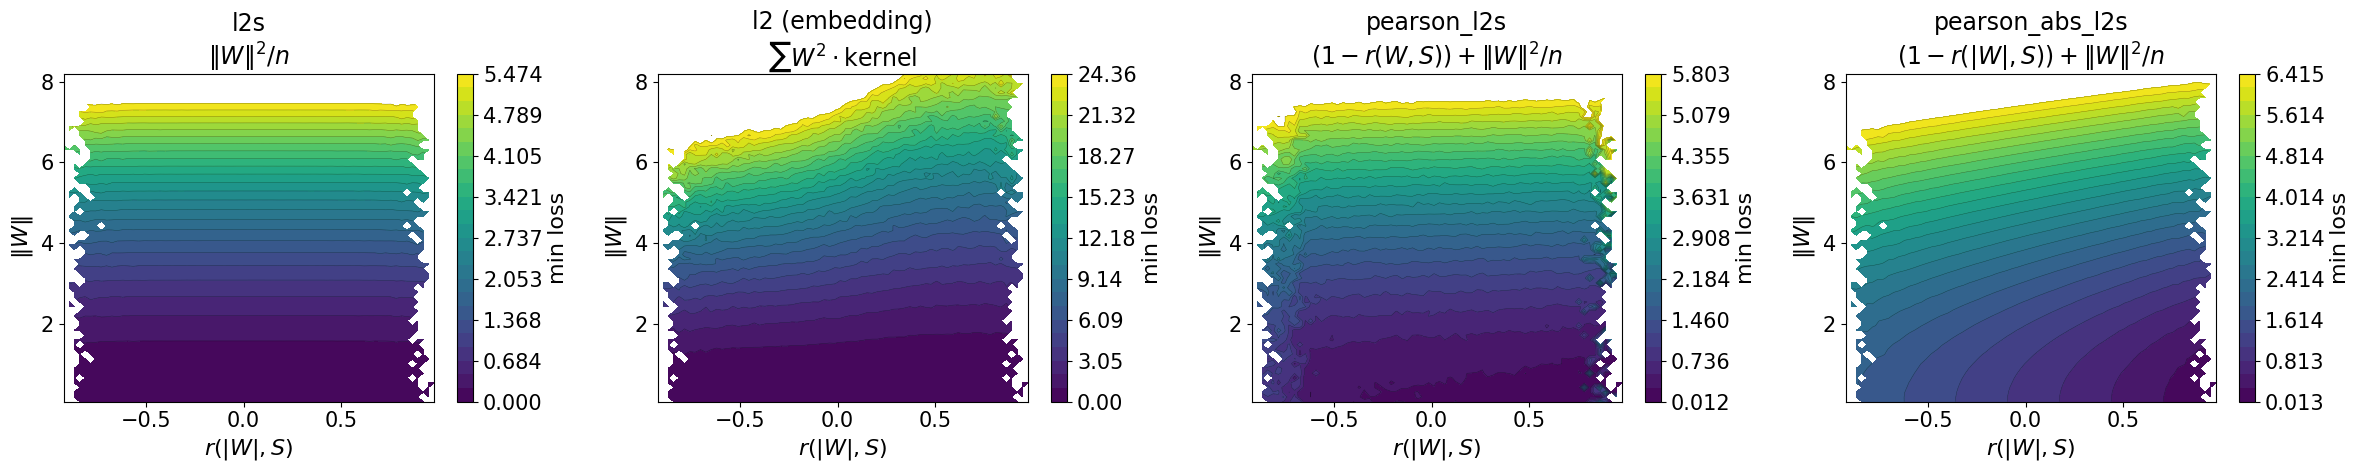

In [61]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, name in zip(axes, LOSS_NAMES):
    data = Z_ra[name]
    levels = np.linspace(np.nanmin(data), np.nanpercentile(data, 90), 25)
    cs = ax.contourf(RAg, MAGg, data, levels=levels, cmap='viridis')
    ax.contour(RAg, MAGg, data, levels=levels, colors='k', linewidths=0.3, alpha=0.5)
    fig.colorbar(cs, ax=ax, label='min loss')
    ax.set_xlabel(r'$r(|W|, S)$')
    ax.set_ylabel(r'$\|W\|$')
    ax.set_title(f'{name}\n{titles[name]}')

plt.tight_layout()
plt.show()

## 3D surfaces over $(r(|W|, S),\ \|W\|)$

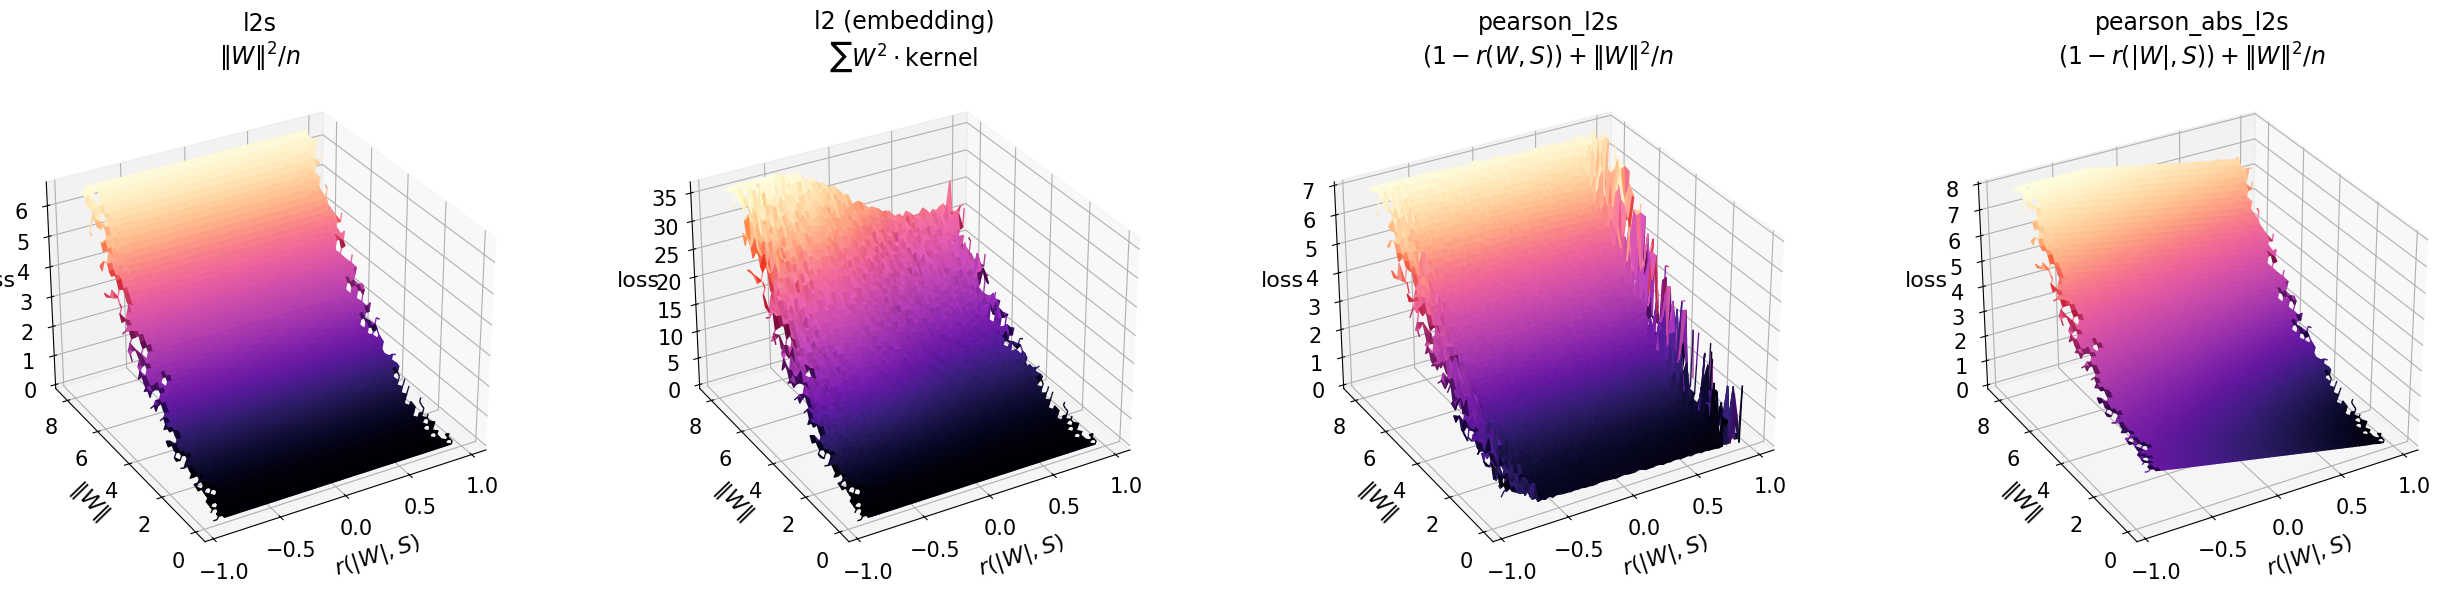

In [62]:
ls = LightSource(azdeg=315, altdeg=45)
cmap = cm.magma

fig, axes = plt.subplots(1, 4, figsize=(26, 6), subplot_kw={'projection': '3d'})

for ax, name in zip(axes, LOSS_NAMES):
    data = Z_ra[name].copy()
    clip_max = np.nanpercentile(data, 99)
    data = np.clip(data, None, clip_max)

    shade_input = np.nan_to_num(data, nan=float(clip_max))
    colors = ls.shade(shade_input, cmap=cmap, blend_mode='soft')
    colors[np.isnan(data)] = [0, 0, 0, 0]   # hide empty bins

    ax.plot_surface(RAg, MAGg, data, facecolors=colors,
                    rstride=1, cstride=1, antialiased=True, shade=False)
    ax.set_xlabel(r'$r(|W|, S)$', labelpad=10)
    ax.set_ylabel(r'$\|W\|$')
    ax.set_zlabel('loss')
    ax.set_title(f'{name}\n{titles[name]}')
    ax.view_init(elev=30, azim=-120)   # face the r(|W|,S) descent

plt.tight_layout()
plt.show()

## The pull toward alignment: $-\partial\,\mathrm{Loss}/\partial r(|W|,S)$

The descent direction along the magnitude-correlation axis, at fixed $\|W\|$:

- **Red** = optimizer pushed toward **higher** $r(|W|,S)$ (the goal); blue = pushed away.
- `pearson_abs_l2s` is uniformly red (constant pull, slope $-1$). `l2`-embedding is red (it pulls, implicitly). `l2s` is ~white (no pull). `pearson_l2s` shows only a weak, indirect pull — it targets the *signed* correlation, a different axis.

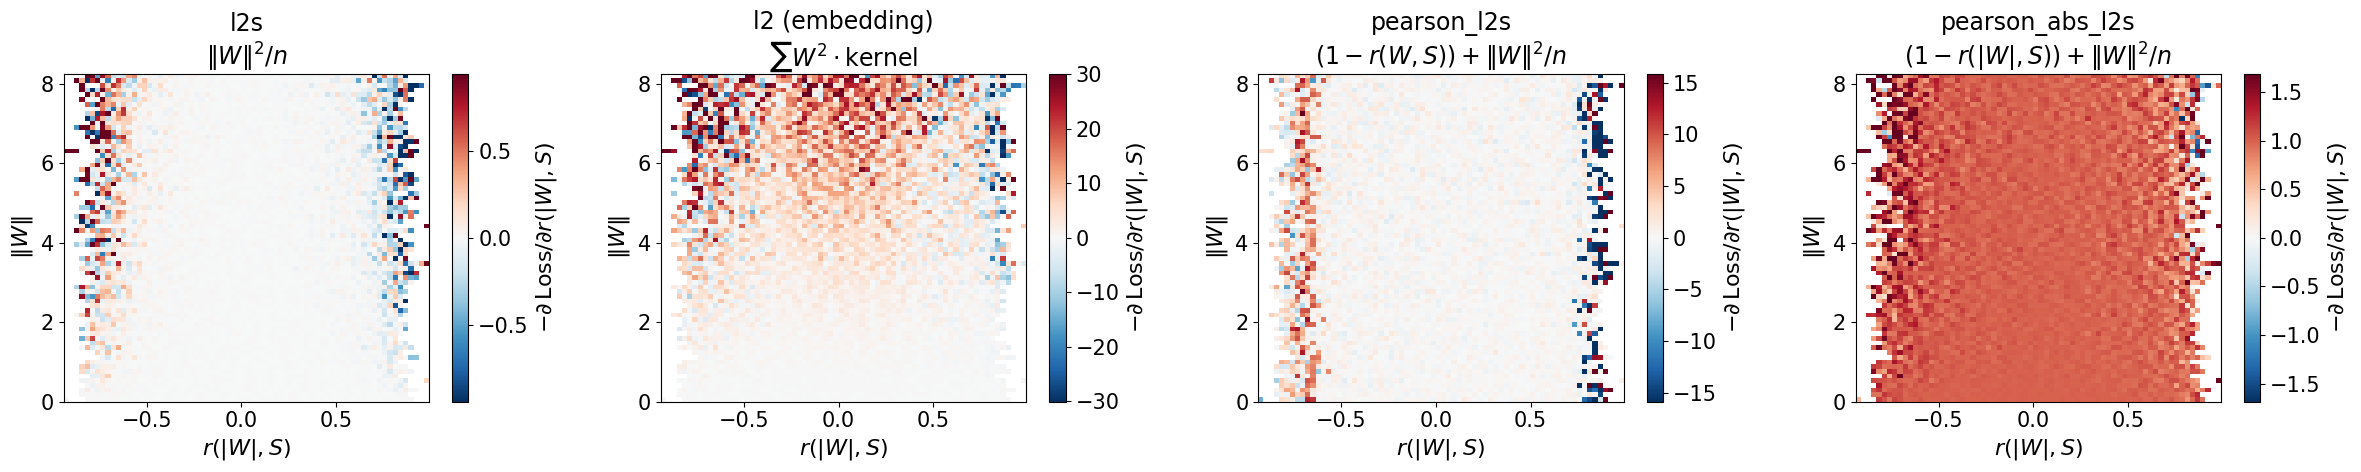

In [63]:
# --- r(|W|,S)-direction pull: -dLoss/dr_abs at fixed magnitude ---
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, name in zip(axes, LOSS_NAMES):
    data = Z_ra[name]
    # gradient over (magnitude, r_abs) axes; keep the r_abs component
    _, dLdra = np.gradient(data, MAG, RA)
    pull = -dLdra  # >0 pushes toward higher r(|W|,S)

    vmax = np.nanpercentile(np.abs(pull), 98)
    vmax = vmax if vmax > 0 else 1.0
    pc = ax.pcolormesh(RAg, MAGg, pull, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       shading='auto')
    fig.colorbar(pc, ax=ax, label=r'$-\partial\,\mathrm{Loss}/\partial r(|W|,S)$')
    ax.set_xlabel(r'$r(|W|, S)$')
    ax.set_ylabel(r'$\|W\|$')
    ax.set_title(f'{name}\n{titles[name]}')

plt.tight_layout()
plt.show()

## Loss vs $r(|W|, S)$ at fixed $\|W\|$ shells

Raw (un-normalized) min loss along the magnitude-correlation axis, at several weight-norm shells. The vertical offset between curves is the $\|W\|^2/n$ bowl; the **slope within a curve** is the alignment reward.

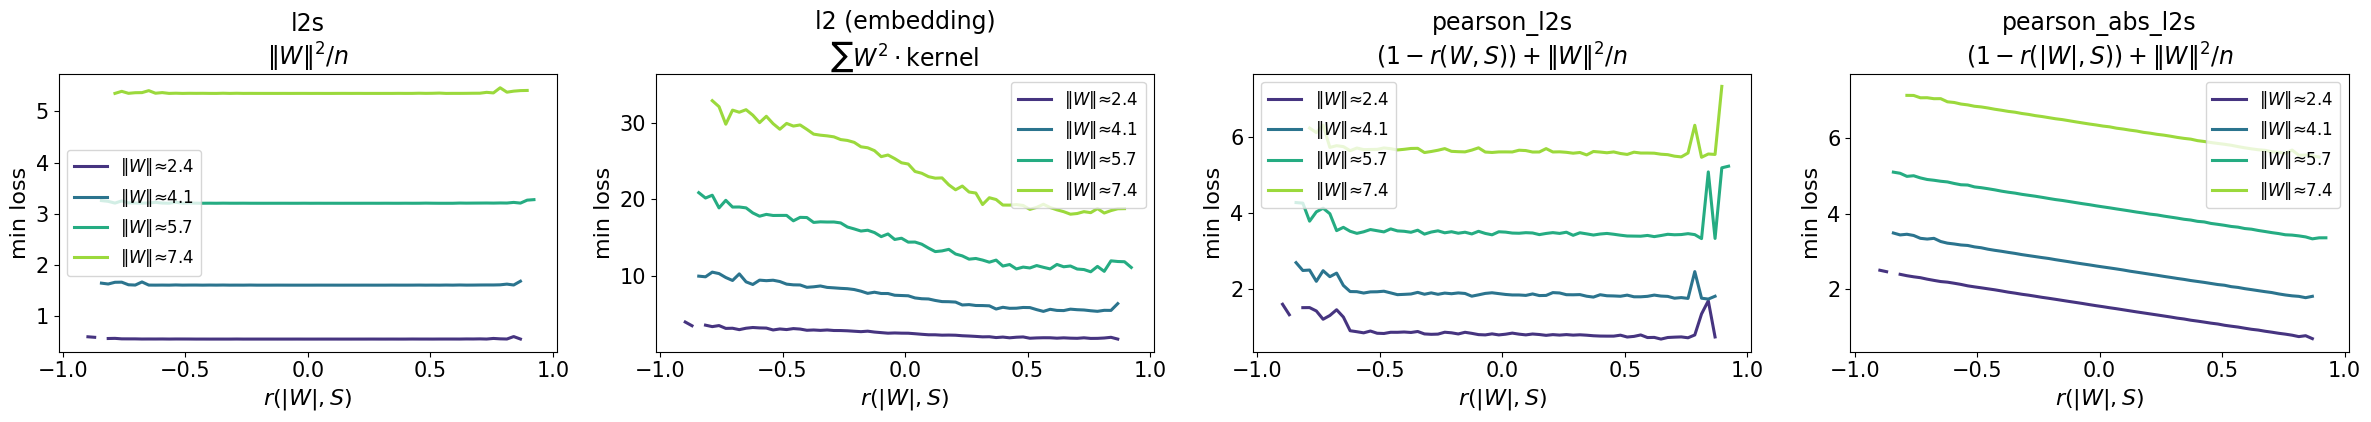

In [64]:
# --- Loss vs r(|W|,S) at fixed magnitude shells ---
mag_fracs = [0.3, 0.5, 0.7, 0.9]
mag_idxs = [int(f * (len(MAG) - 1)) for f in mag_fracs]
shell_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(mag_idxs)))

fig, axes = plt.subplots(1, 4, figsize=(24, 4.5), sharex=True)

for ax, name in zip(axes, LOSS_NAMES):
    data = Z_ra[name]
    for idx, c in zip(mag_idxs, shell_colors):
        profile = data[idx, :]
        if np.all(np.isnan(profile)):
            continue
        ax.plot(RA, profile, color=c, lw=2.2,
                label=f'$\\|W\\|$≈{MAG[idx]:.1f}')
    ax.set_xlabel(r'$r(|W|, S)$')
    ax.set_ylabel('min loss')
    ax.set_title(f'{name}\n{titles[name]}')
    ax.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

## Caveat: the signs stay free

Raising $r(|W|,S)$ does **not** pin the signed correlation $r(W,S)$ — E/I assignment stays free. This is desirable: we want magnitude alignment without forcing every short-range connection to be excitatory. The panels below plot min loss at $\|W\|=1$ over both axes; for the alignment-rewarding losses, low loss runs along high $r(|W|,S)$ (vertical) while spanning the full range of signed $r$ (horizontal) — i.e. the optimizer can hit the target with signs left to do whatever the task needs.

The sampled footprint now spans the **full achievable region**: signed correlation can be created at essentially any $r(|W|,S)$ — including $r(|W|,S)\approx0$ — via sign patterns that track the embedding with (near-)flat magnitude. So the region is *not* a funnel. The only genuine geometric constraint is at the corners: $|r_{\text{signed}}|\to 1$ forces $r(|W|,S)\to 1$, because perfect signed alignment requires the magnitudes to align too.

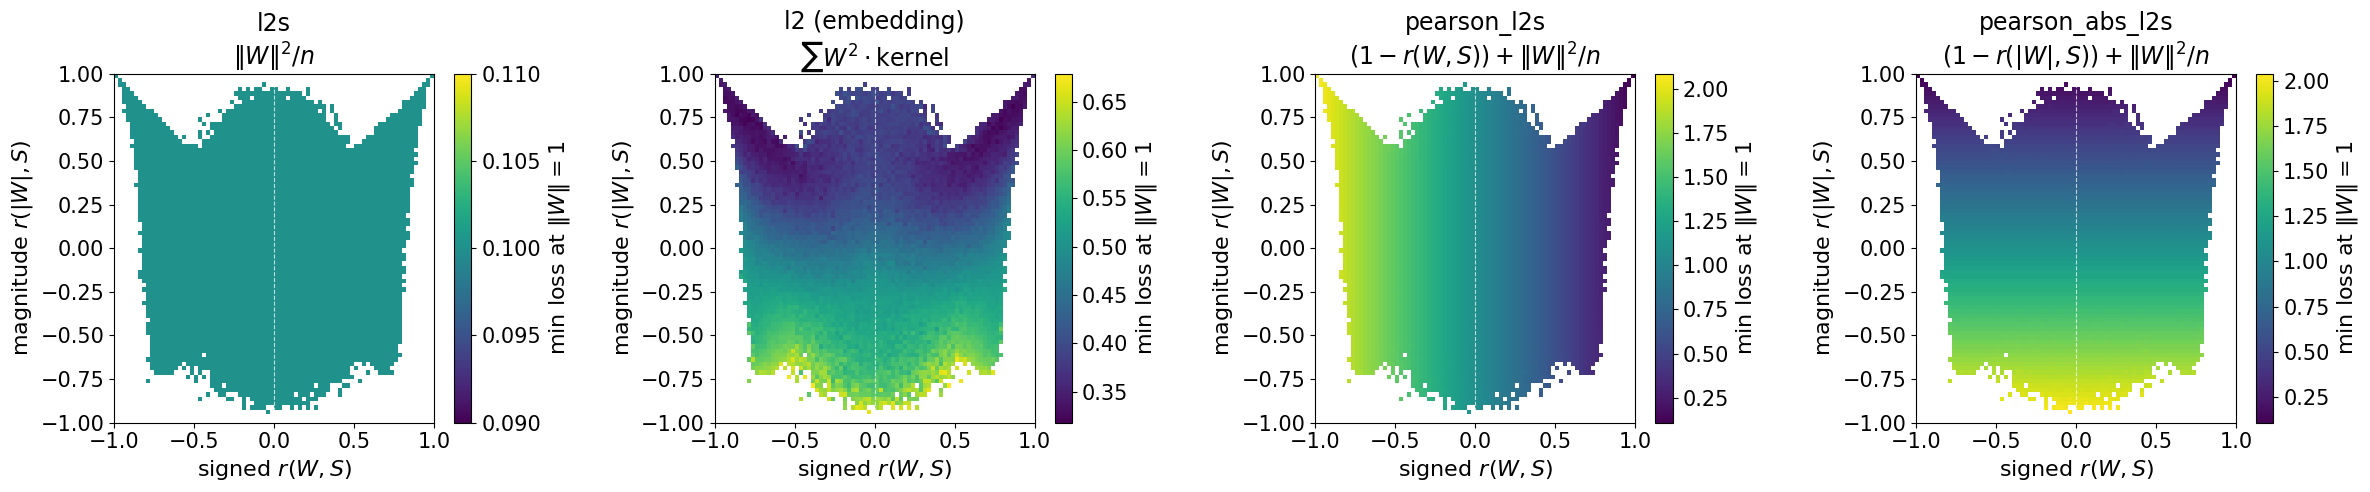

In [65]:
# --- Min loss at ||W||=1 over (signed r, magnitude r) ---
# Reuses the Monte-Carlo backbone (r_signed, r_abs, unit_loss). ||W|| = 1, so
# the magnitude term is constant and only the unit-norm weight pattern matters.
nbins = 80
edges = np.linspace(-1, 1, nbins + 1)
fig, axes = plt.subplots(1, 4, figsize=(24, 5.2))

for ax, name in zip(axes, LOSS_NAMES):
    stat, _, _, _ = binned_statistic_2d(
        r_signed, r_abs, unit_loss[name], statistic='min', bins=[edges, edges])
    grid = stat.T  # rows = magnitude r, cols = signed r
    pc = ax.pcolormesh(edges, edges, grid, cmap='viridis', shading='flat')
    fig.colorbar(pc, ax=ax, label=r'min loss at $\|W\|=1$')
    # if np.isfinite(grid).any():
    #     iy, ix = np.unravel_index(np.nanargmin(grid), grid.shape)
    #     ax.scatter([0.5 * (edges[ix] + edges[ix + 1])],
    #                [0.5 * (edges[iy] + edges[iy + 1])],
    #                marker='*', s=220, c='red', edgecolor='k', zorder=5)
    ax.axvline(0, color='w', lw=0.8, ls='--', alpha=0.7)
    ax.set_xlabel(r'signed $r(W, S)$')
    ax.set_ylabel(r'magnitude $r(|W|, S)$')
    ax.set_title(f'{name}\n{titles[name]}')

plt.tight_layout()
plt.show()